#**Deep Learning Image Classification: Cat vs Dog using MobileNetV2 (Transfer Learning with CNN**)

In [ ]:
!pip install tensorflow

# IMPORT LIBRARIES

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers, models

# Load Dataset

In [ ]:
(train_data, test_data), info = tfds.load(

    'cats_vs_dogs',

    split=['train[:80%]', 'train[80%:]'],

    as_supervised=True,

    with_info=True
)

print(" Dataset Loaded Successfully")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.IY0OGB_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
 Dataset Loaded Successfully


# Image Preprocessing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    return image, label

# Apply Preprocessing

In [ ]:
train_dataset = train_data.map(preprocess)

test_dataset = test_data.map(preprocess)

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(" Preprocessing Complete")

 Preprocessing Complete


# SHOW IMAGES

In [ ]:
dog_images = []
cat_images = []

for img, label in train_dataset.unbatch():

    if label.numpy() == 1 and len(dog_images) < 3:
        dog_images.append(img)

    elif label.numpy() == 0 and len(cat_images) < 3:
        cat_images.append(img)

    if len(dog_images) == 3 and len(cat_images) == 3:
        break

print(" Images Collected")

 Images Collected


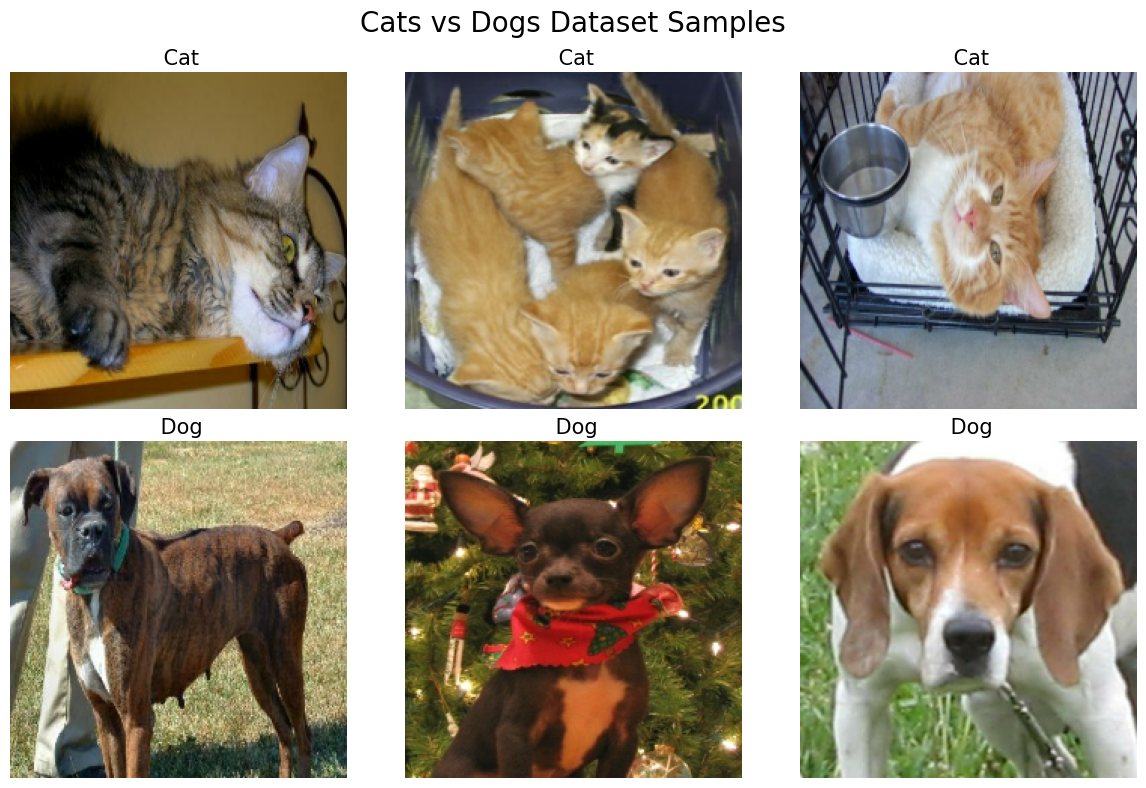

In [ ]:
plt.figure(figsize=(12,8))

# Show Cats
for i in range(3):

    plt.subplot(2,3,i+1)

    plt.imshow(cat_images[i])

    plt.title(" Cat", fontsize=15)

    plt.axis("off")

# Show Dogs
for i in range(3):

    plt.subplot(2,3,i+4)

    plt.imshow(dog_images[i])

    plt.title(" Dog", fontsize=15)

    plt.axis("off")

plt.suptitle("Cats vs Dogs Dataset Samples", fontsize=20)

plt.tight_layout()

plt.show()

#Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

# Load Advanced CNN Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

base_model.trainable = False

print("MobileNetV2 Loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Loaded


# Build Professional Model

In [ ]:
model = models.Sequential([

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')

])

# Compile Model

In [ ]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

print(" Model Compiled")

 Model Compiled


# Model Summary

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train Model

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9591 - loss: 0.1024 - val_accuracy: 0.9850 - val_loss: 0.0412
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 48s 82ms/step - accuracy: 0.9603 - loss: 0.1002 - val_accuracy: 0.9858 - val_loss: 0.0432
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - accuracy: 0.9604 - loss: 0.0978 - val_accuracy: 0.9856 - val_loss: 0.0455
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 81ms/step - accuracy: 0.9628 - loss: 0.0973 - val_accuracy: 0.9832 - val_loss: 0.0482
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 81ms/step - accuracy: 0.9640 - loss: 0.0911 - val_accuracy: 0.9841 - val_loss: 0.0445
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.9648 - loss: 0.0886 - val_accuracy: 0.9862 - val_loss: 0.0445
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.9652 - loss: 0.0874 - val_accuracy: 0.9854 - val_loss: 0.0448
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 46s 80ms/step - accuracy: 0.9657 - loss: 0.0899 - 

#Accuracy & Loss Graphs

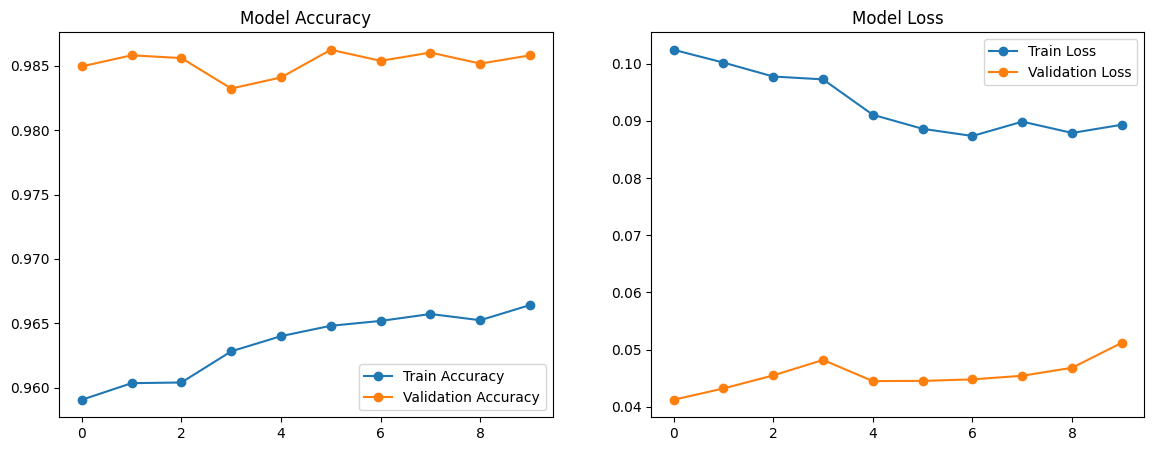

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')

plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')

plt.legend()

plt.title("Model Accuracy")

# Loss Graph
plt.subplot(1,2,2)

plt.plot(epochs_range, loss, marker='o', label='Train Loss')

plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')

plt.legend()

plt.title("Model Loss")

plt.show()

# Final Accuracy

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)

print("Final Accuracy:", test_acc * 100, "%")

146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.9858 - loss: 0.0512
Final Accuracy: 98.58125448226929 %


# Predict Custom Image

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/cat.jpg'

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)
img_array = img_array / 255.0   # same preprocessing
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print(" Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
 Cat


# Model Save & Reuse

In [ ]:
model.save("cats_dogs_model.keras")

In [ ]:
model = tf.keras.models.load_model("cats_dogs_model.keras")

# Confusion Matrix (Professional ML Part)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

# ROC Curve (Advanced ML skill)

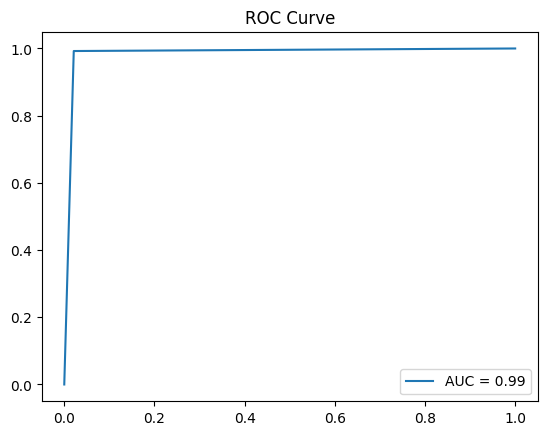

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.legend()
plt.title("ROC Curve")
plt.show()